In [2]:
# Install required packages
!pip3 install seaborn pyarrow

Defaulting to user installation because normal site-packages is not writeable
     |████████████████████████████████| 294 kB 708 kB/s eta 0:00:01
     |████████████████████████████████| 7.8 MB 4.9 MB/s eta 0:00:01
     |████████████████████████████████| 4.7 MB 6.2 MB/s eta 0:00:01
     |████████████████████████████████| 111 kB 25.9 MB/s eta 0:00:01
     |████████████████████████████████| 64 kB 12.8 MB/s eta 0:00:01
     |████████████████████████████████| 2.8 MB 5.0 MB/s eta 0:00:01
     |████████████████████████████████| 249 kB 7.6 MB/s eta 0:00:01
You should consider upgrading via the '/Applications/Xcode.app/Contents/Developer/usr/bin/python3 -m pip install --upgrade pip' command.


In [3]:
import sys
sys.path.append('.')
from m1_m2_demo import run_m1_m2_demo

print("✅ Demo script imported successfully!")

Matplotlib is building the font cache; this may take a moment.


✅ Demo script imported successfully!


🧬 M1-M2 Integration Demo

📁 Step 1: Checking Data Availability
✅ Found 9 files in ../Microbe-vis-data
  📄 gtdb_taxonomy.tsv.gz                               (0.0 GB)
  📄 sandpiper1.0.0.condensed.biorun-metadata.csv.gz    (0.0 GB)
  📄 sandpiper1.0.0.condensed.biosample-metadata.csv.gz (0.0 GB)
  📄 sandpiper1.0.0.condensed.summary.class.csv.gz      (0.0 GB)
  📄 sandpiper1.0.0.condensed.summary.family.csv.gz     (0.1 GB)
  📄 sandpiper1.0.0.condensed.summary.genus.csv.gz      (1.7 GB)
  📄 sandpiper1.0.0.condensed.summary.order.csv.gz      (0.1 GB)
  📄 sandpiper1.0.0.condensed.summary.phylum.csv.gz     (0.0 GB)

🧹 Step 2: Running M1 Data Cleaning
----------------------------------------

⚠️  Warnings/Errors:
/Applications/Xcode.app/Contents/Developer/usr/bin/python3: can't open file '/Users/mhmdfarhat/Documents/projects/Microbiome-Project-Team1/../M1/load&proccess.py': [Errno 2] No such file or directory


✅ Step 3: Verifying M1 Output
----------------------------------------
✅ M1 output fo

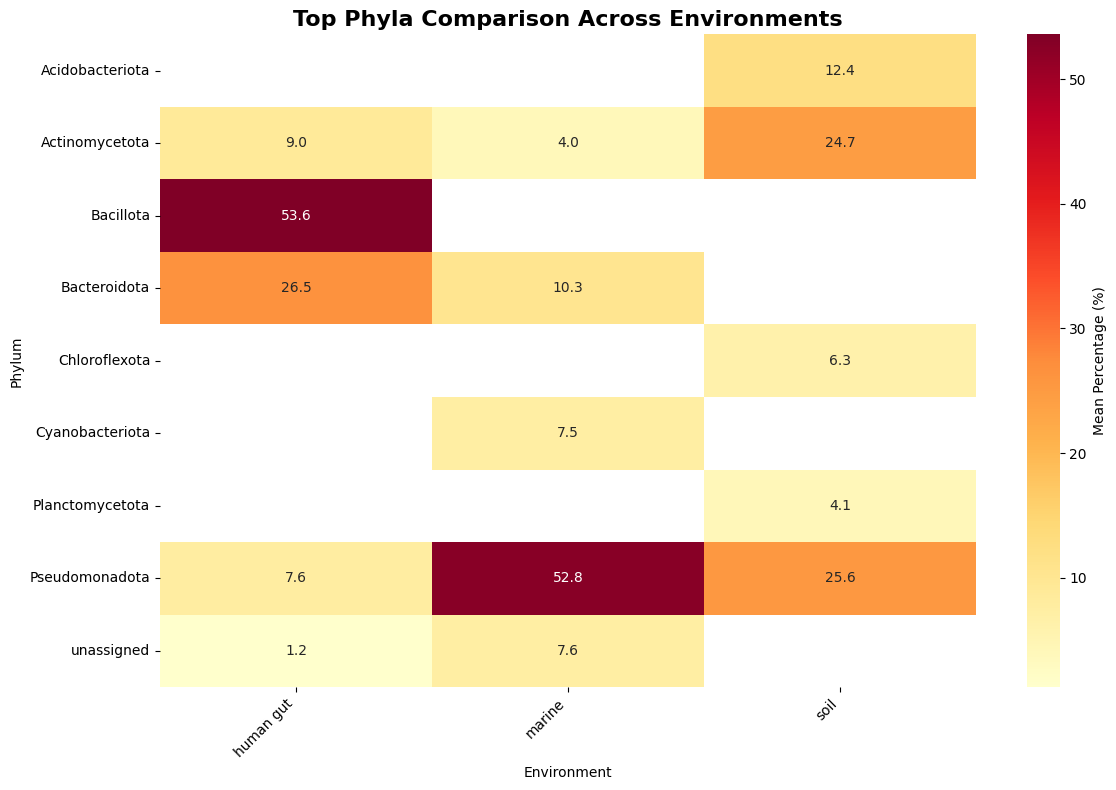

✅ Visualization created!

🎉 Demo completed successfully!

💡 Next steps:
  - Explore different environments
  - Adjust the 'top_n' parameter
  - Try the JSON output format


In [4]:
# Run the complete M1-M2 integration demo!
run_m1_m2_demo()

In [11]:
# Interactive environment explorer
import matplotlib.pyplot as plt
import seaborn as sns

def explore_environment(env_name, top_n=10):
    """Explore a specific environment with M2 backend."""
    print(f"🔬 Exploring: {env_name}")
    print("=" * 60)
    
    try:
        # Import M2 functions
        sys.path.append('../src')
        from utils import load_metadata, average_composition
        
        # Load metadata
        m1_output = "../data/processed/biorun_metadata_clean.parquet"
        df_meta = load_metadata(m1_output)
        
        # Get phylum path
        phylum_path = "../Microbe-vis-data/sandpiper1.0.0.condensed.summary.phylum.csv.gz"
        
        # Compute average composition
        avg_series, n_runs = average_composition(
            env=env_name,
            df_meta=df_meta,
            phylum_path=phylum_path,
            top_n=top_n
        )
        
        if n_runs > 0:
            print(f"✅ Found {n_runs:,} bioruns")
            
            # Create visualization
            fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
            
            # Bar chart of top phyla
            top_phyla = avg_series.head(top_n)
            clean_names = [p.replace('d__Bacteria;p__', '') for p in top_phyla.index]
            
            bars = ax1.barh(range(len(clean_names)), top_phyla.values, color='lightcoral')
            ax1.set_yticks(range(len(clean_names)))
            ax1.set_yticklabels(clean_names)
            ax1.set_xlabel('Mean Percentage (%)')
            ax1.set_title(f'Top {top_n} Phyla in {env_name}', fontweight='bold')
            ax1.grid(axis='x', alpha=0.3)
            
            # Add percentage labels on bars
            for i, (bar, val) in enumerate(zip(bars, top_phyla.values)):
                ax1.text(val + 0.5, bar.get_y() + bar.get_height()/2, f'{val:.1f}%', 
                        ha='left', va='center', fontweight='bold')
            
            # Pie chart
            ax2.pie(top_phyla.values, labels=clean_names, autopct='%1.1f%%', startangle=90)
            ax2.set_title(f'Distribution of Top {top_n} Phyla', fontweight='bold')
            
            plt.tight_layout()
            plt.show()
            
            # Show detailed results
            print(f"\n📊 Top {top_n} Phyla:")
            for i, (taxon, percent) in enumerate(avg_series.head(top_n).items(), 1):
                clean_taxon = taxon.replace('d__Bacteria;p__', '')
                print(f"  {i:2d}. {clean_taxon:<35} {percent:6.2f}%")
                
        else:
            print(f"❌ No bioruns found for '{env_name}'")
            
    except Exception as e:
        print(f"❌ Error exploring '{env_name}': {e}")

print("✅ Interactive explorer ready!")

✅ Interactive explorer ready!


🔬 Exploring: soil metagenome
✅ Found 41,699 bioruns


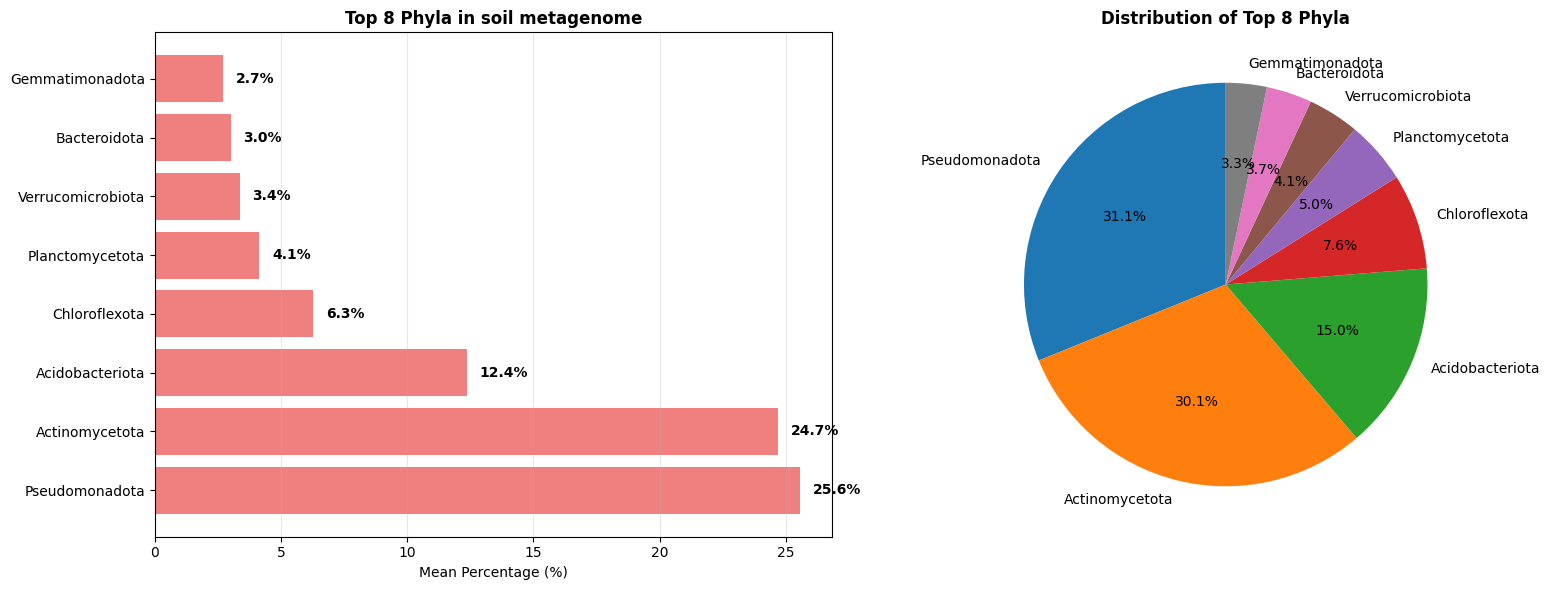


📊 Top 8 Phyla:
   1. Pseudomonadota                       25.56%
   2. Actinomycetota                       24.70%
   3. Acidobacteriota                      12.35%
   4. Chloroflexota                         6.27%
   5. Planctomycetota                       4.14%
   6. Verrucomicrobiota                     3.37%
   7. Bacteroidota                          3.00%
   8. Gemmatimonadota                       2.69%


In [12]:
# Explore soil metagenome
explore_environment("soil metagenome", top_n=8)

🔬 Exploring: marine metagenome
✅ Found 15,342 bioruns


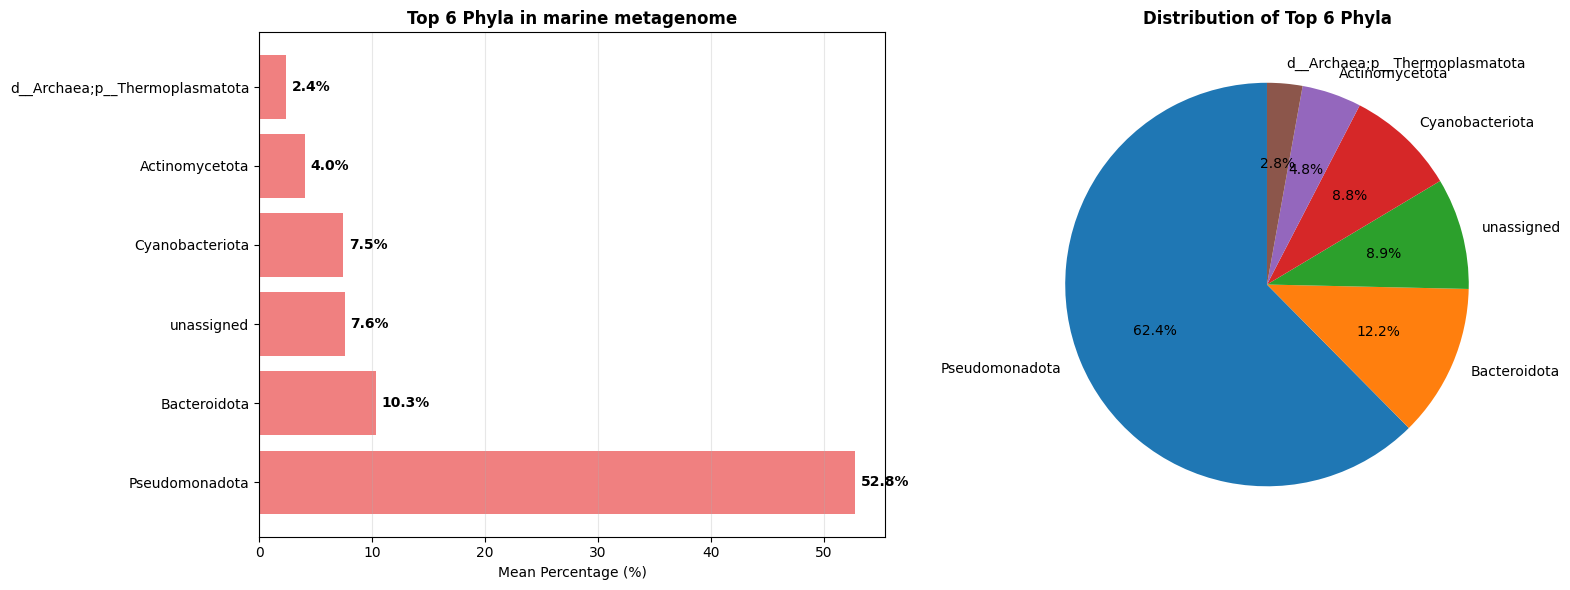


📊 Top 6 Phyla:
   1. Pseudomonadota                       52.77%
   2. Bacteroidota                         10.35%
   3. unassigned                            7.55%
   4. Cyanobacteriota                       7.46%
   5. Actinomycetota                        4.03%
   6. d__Archaea;p__Thermoplasmatota        2.39%


In [13]:
# Explore marine metagenome
explore_environment("marine metagenome", top_n=6)

🔬 Exploring: human gut metagenome
✅ Found 185,185 bioruns


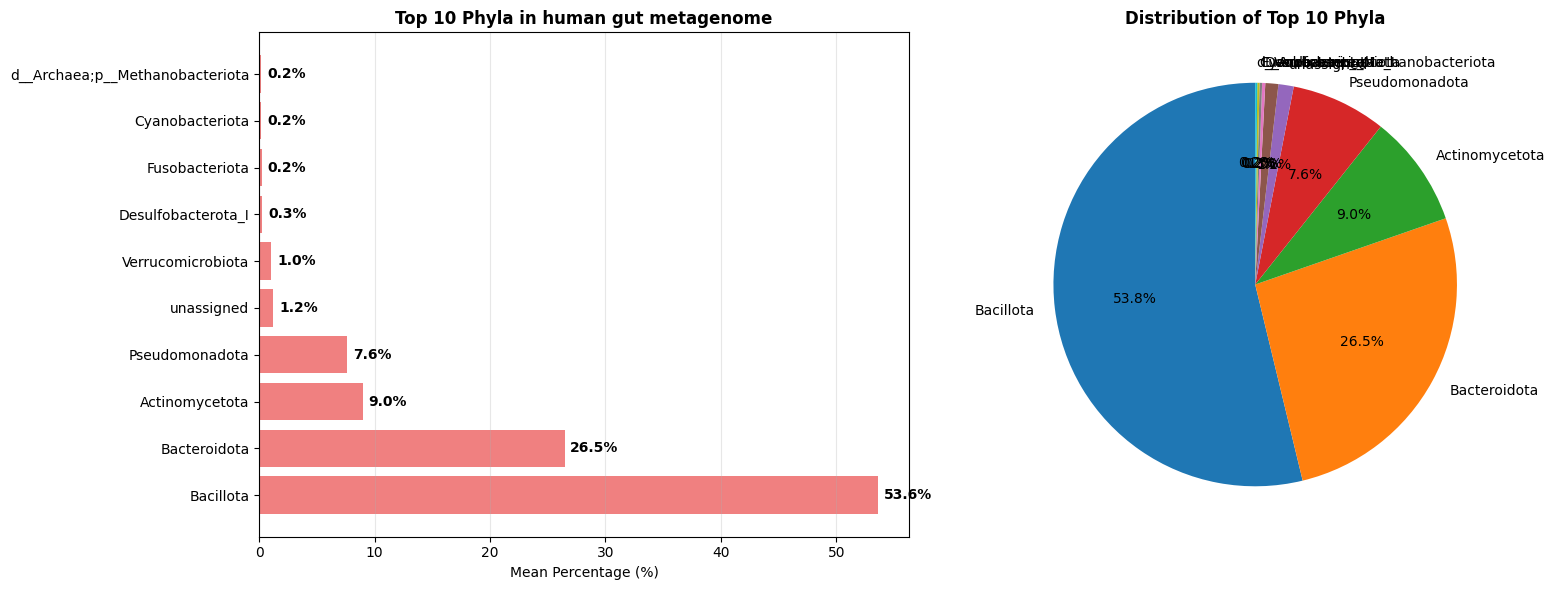


📊 Top 10 Phyla:
   1. Bacillota                            53.61%
   2. Bacteroidota                         26.46%
   3. Actinomycetota                        8.95%
   4. Pseudomonadota                        7.60%
   5. unassigned                            1.22%
   6. Verrucomicrobiota                     1.04%
   7. Desulfobacterota_I                    0.25%
   8. Fusobacteriota                        0.20%
   9. Cyanobacteriota                       0.18%
  10. d__Archaea;p__Methanobacteriota       0.16%


In [14]:
# Explore human gut metagenome
explore_environment("human gut metagenome", top_n=10)

🔬 Exploring: mouse gut metagenome
✅ Found 21,125 bioruns


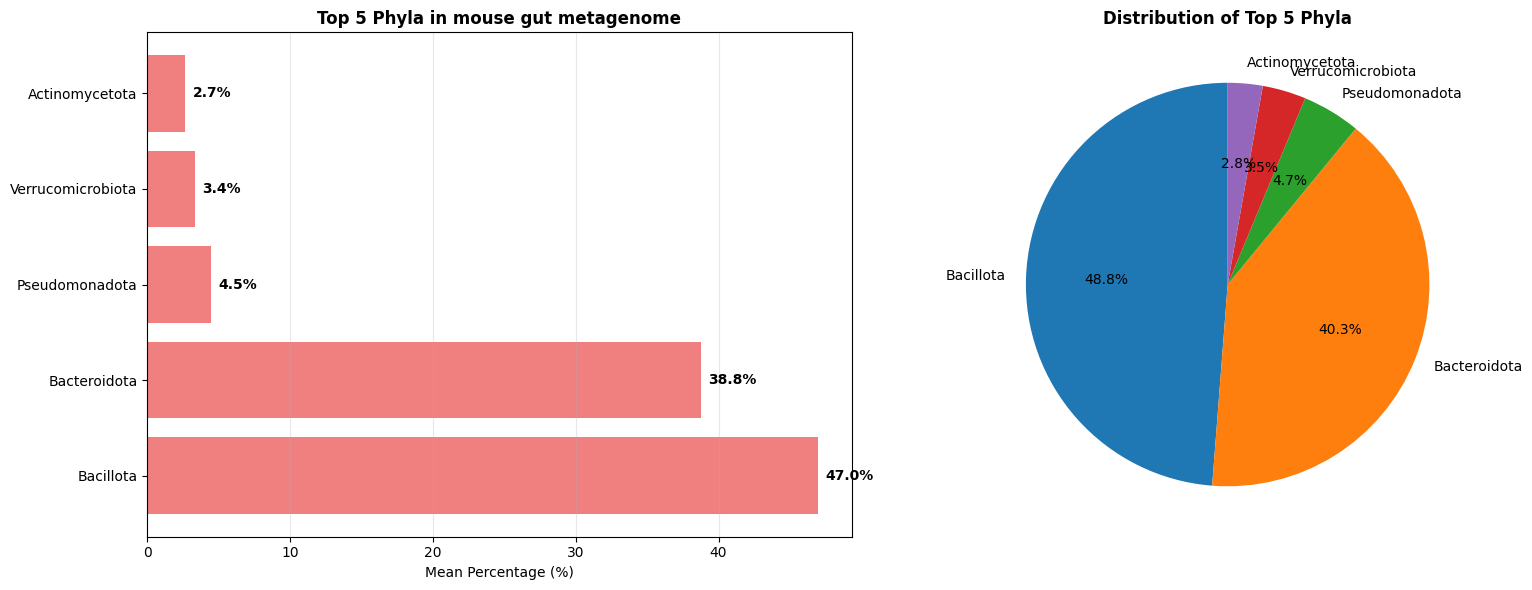


📊 Top 5 Phyla:
   1. Bacillota                            46.98%
   2. Bacteroidota                         38.80%
   3. Pseudomonadota                        4.50%
   4. Verrucomicrobiota                     3.36%
   5. Actinomycetota                        2.69%


In [15]:
# Try any environment you want! Just change the name:
explore_environment("mouse gut metagenome", top_n=5)

In [16]:
# Test M2 Backend JSON Output for M3 Frontend
def test_m2_json_output(env_name, top_n=10):
    """Test M2 backend JSON output format for M3 frontend integration."""
    print(f"🔬 Testing M2 JSON Output for: {env_name}")
    print("=" * 60)
    
    try:
        # Import M2 functions
        sys.path.append('../src')
        from utils import load_metadata, average_composition, as_json_payload
        
        # Load metadata
        m1_output = "../data/processed/biorun_metadata_clean.parquet"
        df_meta = load_metadata(m1_output)
        
        # Get phylum path
        phylum_path = "../Microbe-vis-data/sandpiper1.0.0.condensed.summary.phylum.csv.gz"
        
        # Compute average composition
        avg_series, n_runs = average_composition(
            env=env_name,
            df_meta=df_meta,
            phylum_path=phylum_path,
            top_n=top_n
        )
        
        if n_runs > 0:
            print(f"✅ Found {n_runs:,} bioruns")
            
            # Get JSON payload for M3 frontend
            json_output = as_json_payload(env=env_name, level="phylum", n_runs=n_runs, composition=avg_series)
            
            print(f"\n🔗 M3 Frontend JSON Output:")
            print(json_output)
            
            # Also show the parsed data structure
            import json
            parsed = json.loads(json_output)
            print(f"\n📊 Parsed Structure:")
            print(f"  Environment: {parsed['env']}")
            print(f"  Level: {parsed['level']}")
            print(f"  Bioruns used: {parsed['n_runs']}")
            print(f"  Top phyla count: {len(parsed['composition'])}")
            
            return parsed
            
        else:
            print(f"❌ No bioruns found for '{env_name}'")
            return None
            
    except Exception as e:
        print(f"❌ Error: {e}")
        return None

# Test with different environments
print("🧪 Testing M2 JSON Output for M3 Integration")
print("=" * 60)

# Test soil metagenome
soil_json = test_m2_json_output("soil metagenome", top_n=5)
print("\n" + "="*60)

# Test human gut metagenome  
gut_json = test_m2_json_output("human gut metagenome", top_n=5)

🧪 Testing M2 JSON Output for M3 Integration
🔬 Testing M2 JSON Output for: soil metagenome
✅ Found 41,699 bioruns

🔗 M3 Frontend JSON Output:
{
  "env": "soil metagenome",
  "level": "phylum",
  "n_runs": 41699,
  "composition": [
    {
      "taxon": "d__Bacteria;p__Pseudomonadota",
      "mean_percent": 25.563547567087937
    },
    {
      "taxon": "d__Bacteria;p__Actinomycetota",
      "mean_percent": 24.699883450442456
    },
    {
      "taxon": "d__Bacteria;p__Acidobacteriota",
      "mean_percent": 12.350354205136815
    },
    {
      "taxon": "d__Bacteria;p__Chloroflexota",
      "mean_percent": 6.267544785246649
    },
    {
      "taxon": "d__Bacteria;p__Planctomycetota",
      "mean_percent": 4.138766157461809
    }
  ],
  "unassigned_included": true
}

📊 Parsed Structure:
  Environment: soil metagenome
  Level: phylum
  Bioruns used: 41699
  Top phyla count: 5

🔬 Testing M2 JSON Output for: human gut metagenome
✅ Found 185,185 bioruns

🔗 M3 Frontend JSON Output:
{
  "env":

In [3]:
#!/usr/bin/env python3
import pandas as pd
import os
def main():
    print("=" * 60)
    print("PREVIEW FIRST 100 COLUMNS FROM METADATA FILE")
    print("=" * 60)
    # קובץ המקור הדחוס
    data_file = "../Microbe-vis-data/sandpiper1.0.0.condensed.biosample-metadata.csv.gz"
    if not os.path.exists(data_file):
        print(f"ERROR: File '{data_file}' not found!")
        return
    # טעינת הקובץ (רק את 100 העמודות הראשונות)
    try:
        # טוען רק את שמות העמודות
        all_columns = pd.read_csv(data_file, compression='gzip', nrows=0).columns.tolist()
        first_100_cols = all_columns[:101]
        # טוען רק את 100 העמודות הראשונות
        df = pd.read_csv(data_file, compression='gzip', usecols=first_100_cols)
        print(f"✓ Loaded second 100 columns. Total rows: {len(df):,}")
    except Exception as e:
        print(f"ERROR loading dataset: {e}")
        return
    # הדפסת שמות העמודות
    print("\n:magnifying_glass: First 100 column names:")
    for i, col in enumerate(first_100_cols, start=1):
        print(f"{i:3}. {col}")
    # הדפסת 5 שורות ראשונות מתוך העמודות האלה
    print("\n:page_facing_up: Preview of first 5 rows from selected columns:")
    print(df.head().to_string(index=False))
    # --- שאר הקוד (סינון ושמירה) בהערה ---
    """
    # סינון לפי המילה 'soil' בתוך organism_name
    df_soil = df[df['organism_name'].str.contains('soil', case=False, na=False)]
    print(f"\n✓ Rows containing 'soil': {len(df_soil):,}")
    # שמירה לקובץ חדש
    output_file = "soil_only_organism_names.csv"
    df_soil.to_csv(output_file, index=False)
    print(f"✓ Filtered data saved to '{output_file}'")
    """
    print("=" * 60)
if __name__ == "__main__":
    main()

PREVIEW FIRST 100 COLUMNS FROM METADATA FILE


/var/folders/w0/5zvjdlbn49q1cyx14dkgvq7w0000gn/T/ipykernel_20310/4075396442.py:19: DtypeWarning: Columns (1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,47,48,49,50,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(data_file, compression='gzip', usecols=first_100_cols)


✓ Loaded second 100 columns. Total rows: 432,380

:magnifying_glass: First 100 column names:
  1. biosample
  2. breed
  3. animal_id
  4. sex
  5. condition
  6. age
  7. tissue
  8. biotic_relationship
  9. isol_growth_condt
 10. lat_lon
 11. collection_date
 12. investigation_type
 13. environment
 14. rel_to_oxygen
 15. project_name
 16. ref_biomaterial
 17. alt_elev
 18. num_replicons
 19. trophic_level
 20. country
 21. strain
 22. depth
 23. developmental_stage
 24. sample_name
 25. sample_comment
 26. sub_species
 27. genotype
 28. ecotype
 29. cell_line
 30. read_length
 31. source_name
 32. cell_type
 33. treatment
 34. cultivar
 35. geographic_location_(country_and/or_sea,region)
 36. isolation_source
 37. gap_accession
 38. gap_parent_phs
 39. submitter_handle
 40. biospecimen_repository
 41. study_name
 42. study_design
 43. biospecimen_repository_sample_id
 44. submitted_sample_id
 45. submitted_subject_id
 46. gap_sample_id
 47. gap_subject_id
 48. body_site
 49. histolo